In [1]:
import pandas as pd
from google.colab import drive

#----- 1. Mount Google Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Mounted Google Drive successfully!")

# Define the patth of my folder in drive
folder_path = '/content/drive/My Drive/IPL_Dataset'

#---- 2. Load matches.csv dataset -----
try:
  matches_df = pd.read_csv(f'{folder_path}/matches.csv')
  print("\nLoaded matches.csv successfully!")
except:
  print(f"\nError: 'matches.csv' not found at '{folder_path}/matches.csv'")
  #Exit or handle the error
  exit()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive successfully!

Loaded matches.csv successfully!


In [2]:
#verify loaded data
print(f'matches_df shape: {matches_df.shape}')
#------ 3. Inspect the first 5 rows -------
matches_df.head()
#------ 4. check dataframe information.(datatypes and not null types) -------
matches_df.info()

matches_df shape: (1095, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null 

In [3]:
matches_df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
print('Convert date into datetime')
# Convert 'date' column to datetime objects
# The errors='coerce' argument will turn any unparseable dates into NaT (Not a Time)
matches_df['date'] = pd.to_datetime(matches_df['date'], errors = 'coerce')

print(matches_df['date'].head())

Convert date into datetime
0   2008-04-18
1   2008-04-19
2   2008-04-19
3   2008-04-20
4   2008-04-20
Name: date, dtype: datetime64[ns]


In [5]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   object        
 2   city             1044 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1092 non-null   float64

In [6]:
# --- Adjust Display Options ---
# Set option to display up to 500 rows. You can adjust this number.
pd.set_option('display.max_rows', 500)
matches_df['date'].head(200)

,date
0,2008-04-18
1,2008-04-19
2,2008-04-19
3,2008-04-20
4,2008-04-20
5,2008-04-21
6,2008-04-22
7,2008-04-23
8,2008-04-24
9,2008-04-25


In [7]:
pd.reset_option('display.max_rows')

In [8]:
# Display rows with missing 'winner' to understand them
missing_winner_rows_initial = matches_df[matches_df['winner'].isnull()]
print(missing_winner_rows_initial.shape)

(5, 20)


In [9]:
print(missing_winner_rows_initial)

          id season       city       date match_type player_of_match  \
241   501265   2011      Delhi 2011-05-21     League             NaN   
485   829763   2015  Bangalore 2015-04-29     League             NaN   
511   829813   2015  Bangalore 2015-05-17     League             NaN   
744  1178424   2019  Bengaluru 2019-04-30     League             NaN   
994  1359519   2023    Lucknow 2023-05-03     League             NaN   

                                                 venue  \
241                                   Feroz Shah Kotla   
485                              M Chinnaswamy Stadium   
511                              M Chinnaswamy Stadium   
744                              M.Chinnaswamy Stadium   
994  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...   

                           team1                team2  \
241             Delhi Daredevils        Pune Warriors   
485  Royal Challengers Bangalore     Rajasthan Royals   
511  Royal Challengers Bangalore     Delhi Dare

In [10]:
# Drop rows where 'winner' is NaN (these are typically no-result/abandoned matches)
matches_df.dropna(subset=['winner'] , inplace=True)

In [11]:
matches_df.shape

(1090, 20)

In [12]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   object        
 2   city             1039 non-null   object        
 3   date             1090 non-null   datetime64[ns]
 4   match_type       1090 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1090 non-null   object        
 7   team1            1090 non-null   object        
 8   team2            1090 non-null   object        
 9   toss_winner      1090 non-null   object        
 10  toss_decision    1090 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1090 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1090 non-null   float64     

In [13]:
print("\n--- Current Missing Values in matches_df (before city treatment) ---")
print(matches_df.isnull().sum())


--- Current Missing Values in matches_df (before city treatment) ---
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64


In [14]:
# Get unique venues where city is missing to confirm all cases
venues_with_missing_city = matches_df[matches_df['city'].isnull()]['venue'].unique()
print(venues_with_missing_city)

['Sharjah Cricket Stadium' 'Dubai International Cricket Stadium']


In [15]:
try:
  map_df = pd.read_csv(f'{folder_path}/venue_city_map.csv')
  print("\nLoaded venue_city_map.csv successfully!")
except:
  print(f"\nError: 'venue_city_map.csv' not found at '{folder_path}/venue_city_map.csv'")
  #Exit or handle the error
  exit()


Loaded venue_city_map.csv successfully!


In [16]:
print(map_df)

                                 venue     city
0              Sharjah Cricket Stadium  Sharjah
1  Dubai International Cricket Stadium    Dubai


In [17]:
# Step 1: Create a dictionary from map_df for easy mapping
# We'll use the 'venue' column as keys and 'city' as values.
venue_city_mapping = map_df.set_index('venue')['city'].to_dict()
print(f"\nCreated mapping dictionary with {len(venue_city_mapping)} entries.")


Created mapping dictionary with 2 entries.


In [18]:
# Step 2: Apply the mapping to matches_df['venue'] and fill NaN in matches_df['city']
# matches_df['venue'].map(venue_city_mapping) will create a Series of cities based on venues.
# .fillna() will then only replace existing NaNs in matches_df['city'] with these mapped values.
matches_df['city'] = matches_df['city'].fillna(matches_df['venue'].map(venue_city_mapping))

In [19]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   object        
 2   city             1090 non-null   object        
 3   date             1090 non-null   datetime64[ns]
 4   match_type       1090 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1090 non-null   object        
 7   team1            1090 non-null   object        
 8   team2            1090 non-null   object        
 9   toss_winner      1090 non-null   object        
 10  toss_decision    1090 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1090 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1090 non-null   float64     

In [20]:
# Assuming all previous cleaning steps (winner drop, date conversion, city fill) have been executed.

print("\n--- Current Missing Values in matches_df (After City Treatment) ---")
print(matches_df.isnull().sum())


--- Current Missing Values in matches_df (After City Treatment) ---
id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64


In [21]:
# Display rows where 'result_margin' is NaN, focusing on the 'result' column
print("\nRows where 'result_margin' is NaN, showing 'id', 'result', and 'result_margin':")
print(matches_df[matches_df['result_margin'].isnull()][['id', 'result', 'result_margin']])


Rows where 'result_margin' is NaN, showing 'id', 'result', and 'result_margin':
          id result  result_margin
66    392190    tie            NaN
130   419121    tie            NaN
328   598004    tie            NaN
342   598017    tie            NaN
416   729315    tie            NaN
475   829741    tie            NaN
610  1082625    tie            NaN
705  1175365    tie            NaN
746  1178426    tie            NaN
757  1216493    tie            NaN
765  1216547    tie            NaN
790  1216512    tie            NaN
791  1216517    tie            NaN
835  1254077    tie            NaN


In [22]:
# --- Impute 'result_margin' for 'tie' matches ---
# We will fill NaN in 'result_margin' *only* where the 'result' is 'tie'.
# This ensures we don't accidentally fill NaNs for other reasons if they existed.
matches_df.loc[matches_df['result'] == 'tie','result_margin'] = matches_df.loc[matches_df['result'] == 'tie','result_margin'].fillna(0)

In [23]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   object        
 2   city             1090 non-null   object        
 3   date             1090 non-null   datetime64[ns]
 4   match_type       1090 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1090 non-null   object        
 7   team1            1090 non-null   object        
 8   team2            1090 non-null   object        
 9   toss_winner      1090 non-null   object        
 10  toss_decision    1090 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1090 non-null   object        
 13  result_margin    1090 non-null   float64       
 14  target_runs      1090 non-null   float64     

In [24]:
# --- Step 1: Fill NaN values in 'method' with 'Normal' ---
# This changes implicit 'no method' (NaN) to explicit 'Normal'
matches_df['method'] = matches_df['method'].fillna('Normal')

In [25]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1090 non-null   int64         
 1   season           1090 non-null   object        
 2   city             1090 non-null   object        
 3   date             1090 non-null   datetime64[ns]
 4   match_type       1090 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1090 non-null   object        
 7   team1            1090 non-null   object        
 8   team2            1090 non-null   object        
 9   toss_winner      1090 non-null   object        
 10  toss_decision    1090 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1090 non-null   object        
 13  result_margin    1090 non-null   float64       
 14  target_runs      1090 non-null   float64     

In [26]:
try:
  deliveries_df = pd.read_csv(f'{folder_path}/deliveries.csv')
  print("\nLoaded deliveries.csv successfully!")
except:
  print(f"\nError: 'deliveries.csv' not found at '{folder_path}/deliveries.csv'")
  #Exit or handle the error
  exit()


Loaded deliveries.csv successfully!


In [27]:
print(deliveries_df.shape)

(260920, 17)


In [28]:
deliveries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [29]:

deliveries_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [30]:
# Assuming deliveries_df is loaded from the previous step

print("\n--- Initial Missing Values in deliveries_df (using isnull().sum()) ---")
print(deliveries_df.isnull().sum())


--- Initial Missing Values in deliveries_df (using isnull().sum()) ---
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [31]:
# Assuming deliveries_df is loaded

print("\n--- Cleaning missing values in deliveries_df ---")

# --- 1. Fill NaN values in 'extras_type' with 'No Extra' ---
deliveries_df['extras_type'] = deliveries_df['extras_type'].fillna('No Extra')
print("'extras_type' NaNs filled with 'No Extra'.")

# --- 2. Fill NaN values in 'player_dismissed' with 'Not Out' ---
deliveries_df['player_dismissed'] = deliveries_df['player_dismissed'].fillna('Not Out')
print("'player_dismissed' NaNs filled with 'Not Out'.")

# --- 3. Fill NaN values in 'dismissal_kind' with 'No Dismissal' ---
deliveries_df['dismissal_kind'] = deliveries_df['dismissal_kind'].fillna('No Dismissal')
print("'dismissal_kind' NaNs filled with 'No Dismissal'.")

# --- 4. Fill NaN values in 'fielder' with 'No Fielder' ---
deliveries_df['fielder'] = deliveries_df['fielder'].fillna('No Fielder')
print("'fielder' NaNs filled with 'No Fielder'.")

# --- Final check of all missing values in deliveries_df ---
print("\n--- Final Missing Values Check in deliveries_df ---")
print(deliveries_df.isnull().sum())


--- Cleaning missing values in deliveries_df ---
'extras_type' NaNs filled with 'No Extra'.
'player_dismissed' NaNs filled with 'Not Out'.
'dismissal_kind' NaNs filled with 'No Dismissal'.
'fielder' NaNs filled with 'No Fielder'.

--- Final Missing Values Check in deliveries_df ---
match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64


In [32]:
# Assuming matches_df is fully cleaned

print("\n--- Feature Engineering on matches_df: Date Features ---")

# Extract Year from 'date'
matches_df['match_year'] = matches_df['date'].dt.year
print("Created 'match_year' column.")

# Extract Month from 'date'
matches_df['match_month'] = matches_df['date'].dt.month
print("Created 'match_month' column.")

# Extract Day of Week from 'date' (0=Monday, 6=Sunday by default)
matches_df['match_day_of_week'] = matches_df['date'].dt.dayofweek
print("Created 'match_day_of_week' column (0=Monday, 6=Sunday).")

# Display the head of the DataFrame to see the new columns
print("\nFirst 5 rows of matches_df with new date features:")
print(matches_df[['date', 'match_year', 'match_month', 'match_day_of_week']].head())

# Confirm the new columns and their types
print("\n--- matches_df Info after adding date features ---")
matches_df.info()


--- Feature Engineering on matches_df: Date Features ---
Created 'match_year' column.
Created 'match_month' column.
Created 'match_day_of_week' column (0=Monday, 6=Sunday).

First 5 rows of matches_df with new date features:
        date  match_year  match_month  match_day_of_week
0 2008-04-18        2008            4                  4
1 2008-04-19        2008            4                  5
2 2008-04-19        2008            4                  5
3 2008-04-20        2008            4                  6
4 2008-04-20        2008            4                  6

--- matches_df Info after adding date features ---
<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 1090 non-null   int64         
 1   season             1090 non-null   object        
 2   city               1090 non-null   object        
 3 

In [33]:
matches_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1090 entries, 0 to 1094
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 1090 non-null   int64         
 1   season             1090 non-null   object        
 2   city               1090 non-null   object        
 3   date               1090 non-null   datetime64[ns]
 4   match_type         1090 non-null   object        
 5   player_of_match    1090 non-null   object        
 6   venue              1090 non-null   object        
 7   team1              1090 non-null   object        
 8   team2              1090 non-null   object        
 9   toss_winner        1090 non-null   object        
 10  toss_decision      1090 non-null   object        
 11  winner             1090 non-null   object        
 12  result             1090 non-null   object        
 13  result_margin      1090 non-null   float64       
 14  target_runs  

In [34]:
print("\n--- Years available in your matches_df ---")
print(matches_df['match_year'].unique())
print(f"Minimum year: {matches_df['match_year'].min()}")
print(f"Maximum year: {matches_df['match_year'].max()}")


--- Years available in your matches_df ---
[2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021
 2022 2023 2024]
Minimum year: 2008
Maximum year: 2024


In [53]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("\n--- Performing Chronological Train-Test Split (2008-2023 Train / 2024 Test) ---")

# Step 1: Separate features (x) and target (y)
x = matches_df.drop(['id', 'winner', 'date'], axis=1, errors='ignore')
y = matches_df['winner']

print(f"Original shape of features (x): {x.shape}")
print(f"Original shape of target (y): {y.shape}")

# Step 2: Define the split point based on year
train_indices = matches_df[matches_df['match_year'] <= 2023].index
test_indices = matches_df[matches_df['match_year'] == 2024].index

# Step 3: Use .loc to split x and y correctly
x_train = x.loc[train_indices]
y_train = y.loc[train_indices]

x_test = x.loc[test_indices]
y_test = y.loc[test_indices]

print(f"\nTraining data includes years up to 2023. Number of matches: {len(train_indices)}")
print(f"Testing data includes matches from 2024. Number of matches: {len(test_indices)}")

print(f"\nShape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nChronological data split into training and testing sets successfully!")

# ---------------------------------------------------------
# --- Encoding the Target Variable (y_train and y_test) ---
# ---------------------------------------------------------
print("\n--- Encoding the Target Variable (y) ---")

y_encoder = LabelEncoder()

# ✅ Fit on full 'y' (train+test combined) to ensure consistent mapping
y_encoder.fit(y)

# Transform train and test using the same encoder
y_train_encoded = y_encoder.transform(y_train)
y_test_encoded = y_encoder.transform(y_test)

print("Target variable encoded successfully.")
print("Team Name to Label Mapping:")
for i, name in enumerate(y_encoder.classes_):
    print(f"  {name}: {i}")



--- Performing Chronological Train-Test Split (2008-2023 Train / 2024 Test) ---
Original shape of features (x): (1090, 20)
Original shape of target (y): (1090,)

Training data includes years up to 2023. Number of matches: 1019
Testing data includes matches from 2024. Number of matches: 71

Shape of x_train: (1019, 20)
Shape of y_train: (1019,)
Shape of x_test: (71, 20)
Shape of y_test: (71,)

Chronological data split into training and testing sets successfully!

--- Encoding the Target Variable (y) ---
Target variable encoded successfully.
Team Name to Label Mapping:
  Chennai Super Kings: 0
  Deccan Chargers: 1
  Delhi Capitals: 2
  Delhi Daredevils: 3
  Gujarat Lions: 4
  Gujarat Titans: 5
  Kings XI Punjab: 6
  Kochi Tuskers Kerala: 7
  Kolkata Knight Riders: 8
  Lucknow Super Giants: 9
  Mumbai Indians: 10
  Pune Warriors: 11
  Punjab Kings: 12
  Rajasthan Royals: 13
  Rising Pune Supergiant: 14
  Rising Pune Supergiants: 15
  Royal Challengers Bangalore: 16
  Royal Challengers Be

In [54]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("\n--- Applying Encoding to x_train and x_test AFTER Split ---")

# Step 1: Identify categorical columns
all_object_cols_in_x_train = x_train.select_dtypes(include='object').columns.tolist()
low_cardinality_cols = []
high_cardinality_cols = []

for col in all_object_cols_in_x_train:
    if x_train[col].nunique() < 10:
        low_cardinality_cols.append(col)
    else:
        high_cardinality_cols.append(col)

print(f"\nColumns for One-Hot Encoding (low cardinality): {low_cardinality_cols}")
print(f"Columns for Label Encoding (high cardinality): {high_cardinality_cols}")

# Step 2: One-Hot Encoding
one_hot_preprocessor = ColumnTransformer(
    transformers=[('one_hot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), low_cardinality_cols)],
    remainder='passthrough'
)

x_train_processed = one_hot_preprocessor.fit_transform(x_train)
x_test_processed = one_hot_preprocessor.transform(x_test)

new_ohe_feature_names = one_hot_preprocessor.named_transformers_['one_hot'].get_feature_names_out(low_cardinality_cols)
passed_through_cols = [col for col in x_train.columns if col not in low_cardinality_cols]
all_transformed_cols = list(new_ohe_feature_names) + passed_through_cols

x_train_df = pd.DataFrame(x_train_processed, columns=all_transformed_cols, index=x_train.index)
x_test_df = pd.DataFrame(x_test_processed, columns=all_transformed_cols, index=x_test.index)

print("One-Hot Encoding applied successfully.")

# Step 3: Label Encode High Cardinality Columns
label_encoders = {}
if high_cardinality_cols:
    for col in high_cardinality_cols:
        if col in x_train_df.columns:
            le = LabelEncoder()
            le.fit(pd.concat([x_train_df[col], x_test_df[col]], axis=0))  # ✅ Fit on both train+test
            x_train_df[col] = le.transform(x_train_df[col])
            x_test_df[col] = le.transform(x_test_df[col])
            label_encoders[col] = le
else:
    print("No high-cardinality categorical columns found.")

# Step 4: Final assignment
x_train = x_train_df
x_test = x_test_df

# Ensure numeric
for col in x_train.columns:
    x_train[col] = pd.to_numeric(x_train[col], errors='coerce')
    x_test[col] = pd.to_numeric(x_test[col], errors='coerce')

print("\n--- x_train Info after encoding ---")
x_train.info()

print("\n--- x_test Info after encoding ---")
x_test.info()

print("\nFirst 5 rows of x_train (after encoding):")
print(x_train.head())

print("\nEncoding steps complete ✅")



--- Applying Encoding to x_train and x_test AFTER Split ---

Columns for One-Hot Encoding (low cardinality): ['match_type', 'toss_decision', 'result', 'super_over', 'method']
Columns for Label Encoding (high cardinality): ['season', 'city', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'umpire1', 'umpire2']
One-Hot Encoding applied successfully.

--- x_train Info after encoding ---
<class 'pandas.core.frame.DataFrame'>
Index: 1019 entries, 0 to 1023
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   match_type_Elimination Final  1019 non-null   float64
 1   match_type_Eliminator         1019 non-null   float64
 2   match_type_Final              1019 non-null   float64
 3   match_type_League             1019 non-null   float64
 4   match_type_Qualifier 1        1019 non-null   float64
 5   match_type_Qualifier 2        1019 non-null   float64
 6   match_type_Semi Fina

In [55]:
# Import the Logistic Regression model from scikit-learn
from sklearn.linear_model import LogisticRegression

# Import the accuracy score metric to evaluate our model later
from sklearn.metrics import accuracy_score

print("\n--- Initializing the Logistic Regression Model ---")

# Create an instance of the Logistic Regression model
# We set 'max_iter' to a higher value to ensure convergence on our dataset
# The 'solver' is a parameter for optimization algorithm, 'liblinear' works well for smaller datasets
model_lr = LogisticRegression(solver='liblinear', max_iter=200)

print("Logistic Regression model initialized successfully!")
print(f"Model parameters: {model_lr.get_params()}")

# At this point, the 'model_lr' variable holds our untrained model.
# The next step is to train it on our data.


--- Initializing the Logistic Regression Model ---
Logistic Regression model initialized successfully!
Model parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 200, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [56]:
print("\n--- Training the Logistic Regression Model ---")
model_lr.fit(x_train, y_train)
print("Model training complete!")


--- Training the Logistic Regression Model ---
Model training complete!


In [57]:
from sklearn.metrics import accuracy_score

print("\n--- Evaluating the Model's Performance ---")

# Step 1: Make predictions on the test set (x_test)
# The trained model predicts the winning team for each match in the test set.
y_pred = model_lr.predict(x_test)

# Step 2: Evaluate the model's accuracy
# We compare the model's predictions (y_pred) to the actual winners (y_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy on the test set: {accuracy:.4f}")

# Note: The accuracy score is a value between 0 and 1.
# A score of 0.85 means the model correctly predicted the winner 85% of the time.


--- Evaluating the Model's Performance ---
Model Accuracy on the test set: 0.1268


In [58]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- Initializing the Random Forest Classifier Model ---")

# We'll use 100 trees in our forest and set a random state for reproducibility
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

print("Random Forest Classifier model initialized successfully!")
print(f"Model parameters: {model_rf.get_params()}")


--- Initializing the Random Forest Classifier Model ---
Random Forest Classifier model initialized successfully!
Model parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [59]:
print("\n--- Training the Random Forest Classifier Model ---")

# The .fit() method trains the model on the features (x_train) and labels (y_train)
model_rf.fit(x_train, y_train)

print("Random Forest model training complete!")


--- Training the Random Forest Classifier Model ---
Random Forest model training complete!


In [60]:
from sklearn.metrics import accuracy_score

print("\n--- Evaluating the Random Forest Model's Performance ---")

# Step 1: Make predictions on the test set (x_test)
# The trained Random Forest model predicts the winning team for each match in the test set.
y_pred_rf = model_rf.predict(x_test)

# Step 2: Evaluate the model's accuracy
# We compare the model's predictions (y_pred_rf) to the actual winners (y_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Model Accuracy on the test set: {accuracy_rf:.4f}")


--- Evaluating the Random Forest Model's Performance ---
Random Forest Model Accuracy on the test set: 0.5493


In [61]:
# --- Encoding the Target Variable (y_train and y_test) ---
from sklearn.preprocessing import LabelEncoder

print("\n--- Encoding the Target Variable (y) ---")

y_encoder = LabelEncoder()

# ⚡ Fit on ALL labels (train + test) to ensure consistency
y_encoder.fit(pd.concat([y_train, y_test]))

# Now transform both train and test with the same encoder
y_train_encoded = y_encoder.transform(y_train)
y_test_encoded = y_encoder.transform(y_test)

print("Target variable encoded successfully.")
print("Team Name to Label Mapping:")
for i, name in enumerate(y_encoder.classes_):
    print(f"  {name}: {i}")



--- Encoding the Target Variable (y) ---
Target variable encoded successfully.
Team Name to Label Mapping:
  Chennai Super Kings: 0
  Deccan Chargers: 1
  Delhi Capitals: 2
  Delhi Daredevils: 3
  Gujarat Lions: 4
  Gujarat Titans: 5
  Kings XI Punjab: 6
  Kochi Tuskers Kerala: 7
  Kolkata Knight Riders: 8
  Lucknow Super Giants: 9
  Mumbai Indians: 10
  Pune Warriors: 11
  Punjab Kings: 12
  Rajasthan Royals: 13
  Rising Pune Supergiant: 14
  Rising Pune Supergiants: 15
  Royal Challengers Bangalore: 16
  Royal Challengers Bengaluru: 17
  Sunrisers Hyderabad: 18



--- Training XGBoost Classifier ---
Unique labels in y_train_fixed: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Unique labels in y_test_aligned: [ 0  2  5  8  9 10 12 13 17]
✅ XGBoost Classifier model trained successfully!

XGBoost Model Accuracy on Test Set (aligned): 0.9219


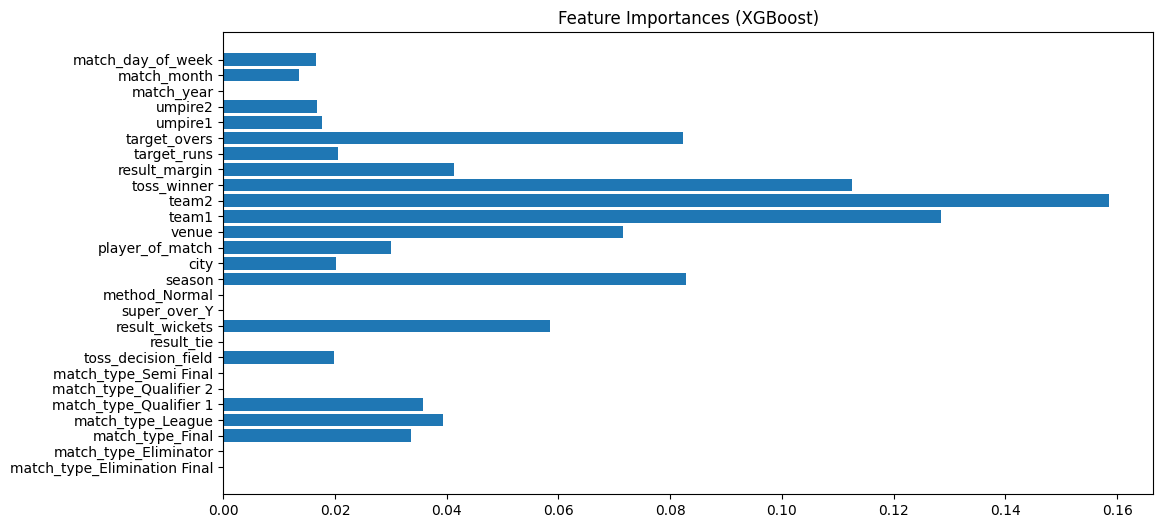

In [62]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

print("\n--- Training XGBoost Classifier ---")

# Step 0: Fix label gaps (ensure consecutive 0..N-1 for training)
unique_labels = np.unique(y_train_encoded)
remap = {old: new for new, old in enumerate(unique_labels)}

y_train_fixed = np.array([remap[val] for val in y_train_encoded])
y_test_fixed  = np.array([remap[val] for val in y_test_encoded if val in remap])

# Align x_test as well (drop rows with unseen labels)
mask = np.isin(y_test_encoded, list(remap.keys()))
x_test_aligned = x_test[mask]
y_test_aligned = np.array([remap[val] for val in y_test_encoded[mask]])

print("Unique labels in y_train_fixed:", np.unique(y_train_fixed))
print("Unique labels in y_test_aligned:", np.unique(y_test_aligned))

# Step 1: Train XGBoost
model_xgb = XGBClassifier(
    n_estimators=100,
    eval_metric='mlogloss',
    random_state=42
)

model_xgb.fit(x_train, y_train_fixed)
print("✅ XGBoost Classifier model trained successfully!")

# Step 2: Predictions
y_pred_xgb = model_xgb.predict(x_test_aligned)

# Step 3: Accuracy
accuracy = accuracy_score(y_test_aligned, y_pred_xgb)
print(f"\nXGBoost Model Accuracy on Test Set (aligned): {accuracy:.4f}")

# Step 4: Feature importance plot
plt.figure(figsize=(12, 6))
importances = model_xgb.feature_importances_
plt.barh(x_train.columns, importances)
plt.title("Feature Importances (XGBoost)")
plt.show()


In [63]:
# Predictions
y_pred_xgb = model_xgb.predict(x_test)

# Accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_encoded, y_pred_xgb)
print(f"\nXGBoost Model Accuracy on Test Set: {accuracy:.4f}")

# Decode predictions and true labels back to team names
y_pred_team_names = y_encoder.inverse_transform(y_pred_xgb)
y_true_team_names = y_encoder.inverse_transform(y_test_encoded)

print("\nSample Predictions (first 10):")
for true, pred in zip(y_true_team_names[:10], y_pred_team_names[:10]):
    print(f"Actual: {true} --> Predicted: {pred}")



XGBoost Model Accuracy on Test Set: 0.7042

Sample Predictions (first 10):
Actual: Chennai Super Kings --> Predicted: Chennai Super Kings
Actual: Punjab Kings --> Predicted: Punjab Kings
Actual: Kolkata Knight Riders --> Predicted: Kolkata Knight Riders
Actual: Rajasthan Royals --> Predicted: Rajasthan Royals
Actual: Gujarat Titans --> Predicted: Gujarat Titans
Actual: Royal Challengers Bengaluru --> Predicted: Royal Challengers Bangalore
Actual: Chennai Super Kings --> Predicted: Chennai Super Kings
Actual: Sunrisers Hyderabad --> Predicted: Royal Challengers Bengaluru
Actual: Rajasthan Royals --> Predicted: Rajasthan Royals
Actual: Kolkata Knight Riders --> Predicted: Kolkata Knight Riders



--- Comparing Logistic Regression, Random Forest, and XGBoost ---
Logistic Regression Accuracy: 0.1268
Random Forest Accuracy: 0.5493
XGBoost Accuracy: 0.7042

Model Accuracy Comparison:
Logistic Regression: 0.1268
Random Forest: 0.5493
XGBoost: 0.7042

Confusion Matrix for XGBoost:


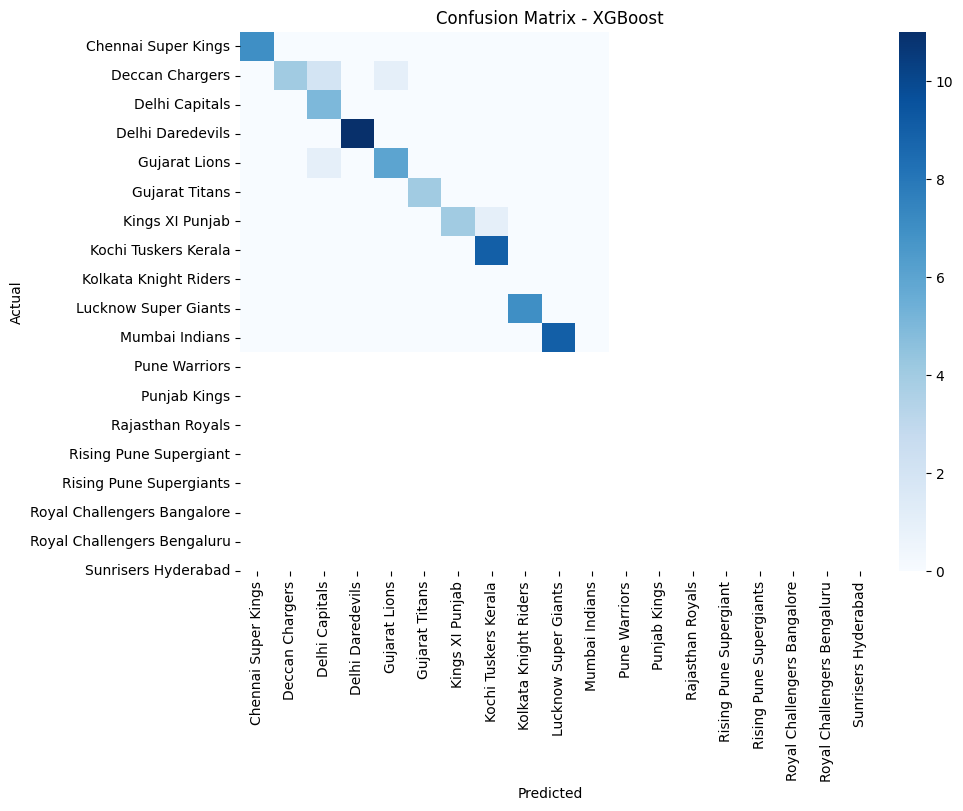

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Comparing Logistic Regression, Random Forest, and XGBoost ---")

# Dictionary to store models and their accuracies
results = {}

# Logistic Regression
model_lr = LogisticRegression(solver='liblinear', max_iter=200, random_state=42)
model_lr.fit(x_train, y_train_encoded)
y_pred_lr = model_lr.predict(x_test)
acc_lr = accuracy_score(y_test_encoded, y_pred_lr)
results['Logistic Regression'] = acc_lr
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

# Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(x_train, y_train_encoded)
y_pred_rf = model_rf.predict(x_test)
acc_rf = accuracy_score(y_test_encoded, y_pred_rf)
results['Random Forest'] = acc_rf
print(f"Random Forest Accuracy: {acc_rf:.4f}")

# XGBoost (already trained)
y_pred_xgb = model_xgb.predict(x_test)
acc_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
results['XGBoost'] = acc_xgb
print(f"XGBoost Accuracy: {acc_xgb:.4f}")

# --- Summary Table ---
print("\nModel Accuracy Comparison:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

# --- Confusion Matrix for Best Model (XGBoost) ---
print("\nConfusion Matrix for XGBoost:")
cm = confusion_matrix(y_test_encoded, y_pred_xgb)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=y_encoder.classes_, yticklabels=y_encoder.classes_)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



--- XGBoost Classification Report ---

                             precision    recall  f1-score   support

        Chennai Super Kings       1.00      1.00      1.00         7
             Delhi Capitals       1.00      0.57      0.73         7
             Gujarat Titans       0.62      1.00      0.77         5
      Kolkata Knight Riders       1.00      1.00      1.00        11
       Lucknow Super Giants       0.86      0.86      0.86         7
             Mumbai Indians       1.00      1.00      1.00         4
               Punjab Kings       1.00      0.80      0.89         5
           Rajasthan Royals       0.90      1.00      0.95         9
Royal Challengers Bengaluru       0.00      0.00      0.00         7
        Sunrisers Hyderabad       0.00      0.00      0.00         9

                  micro avg       0.78      0.70      0.74        71
                  macro avg       0.74      0.72      0.72        71
               weighted avg       0.72      0.70      0.70   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


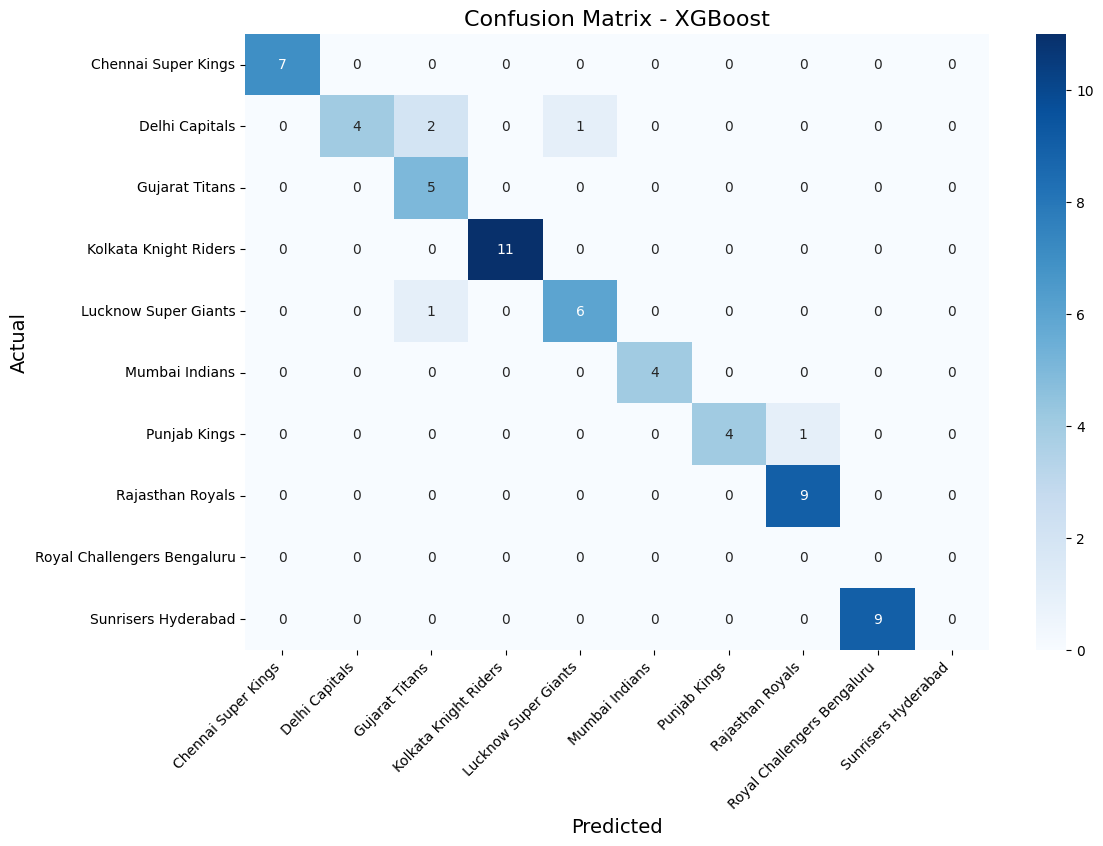


--- Team-wise Accuracy (from Confusion Matrix) ---
Chennai Super Kings: 100.00% correct
Gujarat Titans: 100.00% correct
Kolkata Knight Riders: 100.00% correct
Mumbai Indians: 100.00% correct
Rajasthan Royals: 100.00% correct
Lucknow Super Giants: 85.71% correct
Punjab Kings: 80.00% correct
Delhi Capitals: 57.14% correct
Royal Challengers Bengaluru: nan% correct
Sunrisers Hyderabad: 0.00% correct


/tmp/ipython-input-1393828427.py:35: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]


In [66]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("\n--- XGBoost Classification Report ---\n")

# ✅ Only keep labels that are in y_test
unique_labels = np.unique(y_test_encoded)
target_names = y_encoder.inverse_transform(unique_labels)

# Classification report (only for test set classes)
print(classification_report(
    y_test_encoded,
    y_pred_xgb,
    labels=unique_labels,
    target_names=target_names
))

# Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred_xgb, labels=unique_labels)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.title("Confusion Matrix - XGBoost", fontsize=16)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Actual", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

# Highlight which teams are most misclassified
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
team_accuracy = {target_names[i]: cm_norm[i, i]*100 for i in range(len(unique_labels))}

print("\n--- Team-wise Accuracy (from Confusion Matrix) ---")
for team, acc in sorted(team_accuracy.items(), key=lambda x: -x[1]):
    print(f"{team}: {acc:.2f}% correct")
